In [1]:

# 21. Load the NLTK movie_reviews dataset and count the number of positive and negative reviews.
# 22. Extract the top 2000 frequent words from the movie_reviews corpus and print them.
# 23. Create a function that checks whether specific words exist in a review text and returns True/False.
# 24. Prepare feature sets using the movie_reviews dataset and split them into training and testing data.
# 25. Train a Naive Bayes classifier using the movie_reviews dataset and print the accuracy.
# 26. Display the top 10 most informative features of the Naive Bayes classifier.
# 27. Write a function that takes a custom sentence and predicts if it is positive or negative using the trained model.
# 28. Save the trained Naive Bayes classifier using pickle and load it again to make predictions.
# 29. Perform text preprocessing (tokenization, stopword removal, lemmatization) on user input text.
# 30. Create a complete text classification pipeline using NLTK from raw text to sentiment prediction

In [2]:
# 1. Import the NLTK library and check its version installed on your system.
import nltk

print(nltk.__version__)

3.9.2


In [3]:
# 2. Download all required NLTK resources (punkt, stopwords, wordnet, averaged_perceptron_tagger_eng) using nltk.download().
nltk.download('punkt_tab')        # for tokenization
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')

from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk import pos_tag, FreqDist


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [4]:
# 3. Write a Python program to tokenize a given paragraph into sentences using sent_tokenize().
paragraph = """Natural Language Processing (NLP) is a fascinating field of Artificial Intelligence.
It helps computers understand, interpret, and respond to human language.
Learning NLP opens many opportunities in data science and machine learning."""
sentences = sent_tokenize(paragraph)
print("\nSentences:\n", sentences)


Sentences:
 ['Natural Language Processing (NLP) is a fascinating field of Artificial Intelligence.', 'It helps computers understand, interpret, and respond to human language.', 'Learning NLP opens many opportunities in data science and machine learning.']


In [5]:
# 4. Tokenize the same paragraph into individual words using word_tokenize().
words = word_tokenize(paragraph)
print("\nWords:\n", words)



Words:
 ['Natural', 'Language', 'Processing', '(', 'NLP', ')', 'is', 'a', 'fascinating', 'field', 'of', 'Artificial', 'Intelligence', '.', 'It', 'helps', 'computers', 'understand', ',', 'interpret', ',', 'and', 'respond', 'to', 'human', 'language', '.', 'Learning', 'NLP', 'opens', 'many', 'opportunities', 'in', 'data', 'science', 'and', 'machine', 'learning', '.']


In [6]:
# 5. Remove stopwords from a given text using NLTK stopwords list.
stop_words = set(stopwords.words('english'))
filtered_words = [w for w in words if w.lower() not in stop_words]
print("\nAfter Removing Stopwords:\n", filtered_words)



After Removing Stopwords:
 ['Natural', 'Language', 'Processing', '(', 'NLP', ')', 'fascinating', 'field', 'Artificial', 'Intelligence', '.', 'helps', 'computers', 'understand', ',', 'interpret', ',', 'respond', 'human', 'language', '.', 'Learning', 'NLP', 'opens', 'many', 'opportunities', 'data', 'science', 'machine', 'learning', '.']


In [7]:
# 6. Perform stemming on a list of words using the PorterStemmer and print the output.
from nltk.stem import PorterStemmer
ps = PorterStemmer()
stemmed_words = [ps.stem(w) for w in filtered_words]
print("\nStemmed Words:\n", stemmed_words)



Stemmed Words:
 ['natur', 'languag', 'process', '(', 'nlp', ')', 'fascin', 'field', 'artifici', 'intellig', '.', 'help', 'comput', 'understand', ',', 'interpret', ',', 'respond', 'human', 'languag', '.', 'learn', 'nlp', 'open', 'mani', 'opportun', 'data', 'scienc', 'machin', 'learn', '.']


In [8]:
# 7. Perform lemmatization on the same list of words using WordNetLemmatizer and compare results with stemming.
lemmatizer = WordNetLemmatizer()
lemmatized_words = [lemmatizer.lemmatize(w) for w in filtered_words]
print("\nLemmatized Words:\n", lemmatized_words)



Lemmatized Words:
 ['Natural', 'Language', 'Processing', '(', 'NLP', ')', 'fascinating', 'field', 'Artificial', 'Intelligence', '.', 'help', 'computer', 'understand', ',', 'interpret', ',', 'respond', 'human', 'language', '.', 'Learning', 'NLP', 'open', 'many', 'opportunity', 'data', 'science', 'machine', 'learning', '.']


In [9]:
# 8. Apply Part of Speech (POS) tagging to a given sentence and print each word with its tag.
sentence = "NLP makes machines intelligent"
pos_tags = pos_tag(word_tokenize(sentence))
print("\nPOS Tags:\n", pos_tags)


POS Tags:
 [('NLP', 'NNP'), ('makes', 'VBZ'), ('machines', 'NNS'), ('intelligent', 'NN')]


In [10]:
# 9. Perform frequency distribution on a paragraph and print the top 10 most frequent words.
from nltk import FreqDist
fdist = FreqDist(filtered_words)
for word, freq in fdist.most_common(10):  # show top 10
    print(f"{word}: {freq}")

.: 3
NLP: 2
,: 2
Natural: 1
Language: 1
Processing: 1
(: 1
): 1
fascinating: 1
field: 1


<Axes: title={'center': 'Top 15 Word Frequencies'}, xlabel='Samples', ylabel='Counts'>

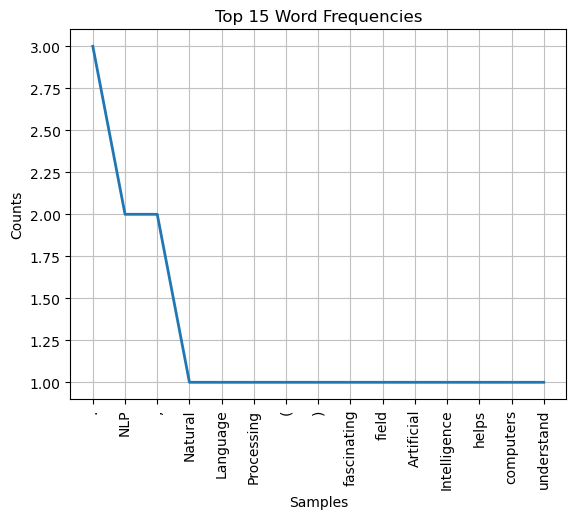

In [25]:
# 10. Plot a graph of the top 15 most frequent words using FreqDist().plot().
fdist.plot(15, title="Top 15 Word Frequencies")

In [ ]:
# 11. Perform Named Entity Recognition (NER) on a text containing names of people, places, and organizations.
text = "Elon Musk is the CEO of Tesla and lives in the United States. Sundar Pichai works at Google in California."

words = word_tokenize(text)

pos_tags = pos_tag(words)


In [11]:
# 12. Create a function that accepts text input and returns a list of nouns and verbs separately using POS tagging.

text = "She is learning Python and building projects"

def get_nouns_and_verbs(text):
    words = word_tokenize(text)
    tags = pos_tag(words)

    nouns = []
    verbs = []

    for word, tag in tags:
        if tag.startswith("NN"):
            nouns.append(word)
        elif tag.startswith("VB"):
            verbs.append(word)

    return nouns, verbs
    
nouns, verbs = get_nouns_and_verbs(text)

print("Nouns:", nouns)
print("Verbs:", verbs)

Nouns: ['Python', 'building', 'projects']
Verbs: ['is', 'learning']


In [12]:
# 13. Count the number of adjectives and adverbs present in a given text.
text = "She is a very beautiful girl who speaks extremely softly and looks quite happy."

words = word_tokenize(text)

tags = pos_tag(words)

adj_count = 0
adv_count = 0

for word, tag in tags:
    if tag.startswith("JJ"):   # Adjectives
        adj_count += 1
    elif tag.startswith("RB"): # Adverbs
        adv_count += 1

print("Adjectives:", adj_count)
print("Adverbs:", adv_count)

Adjectives: 2
Adverbs: 4


In [13]:
# 14. Tokenize a paragraph and find the average length of words using NLTK functions.
text = "Natural Language Processing helps computers understand human language better."

# Tokenize paragraph into words
words = word_tokenize(text)

# Keep only alphabetic words (remove punctuation)
words = [w for w in words if w.isalpha()]

# Total characters in all words
total_length = sum(len(w) for w in words)

# Number of words
count = len(words)

# Average word length
average = total_length / count

print("Words:", words)
print("Average Word Length:", average)

Words: ['Natural', 'Language', 'Processing', 'helps', 'computers', 'understand', 'human', 'language', 'better']
Average Word Length: 7.555555555555555


In [14]:
# 15. Write a program to find all unique words from a text using tokenization and set().
text = "Python is easy and Python is powerful for data science and machine learning"

# Tokenize words
words = word_tokenize(text)

# Convert to set to get unique words
unique_words = set(words)

print("All Words:", words)
print("Unique Words:", unique_words)

All Words: ['Python', 'is', 'easy', 'and', 'Python', 'is', 'powerful', 'for', 'data', 'science', 'and', 'machine', 'learning']
Unique Words: {'for', 'powerful', 'Python', 'easy', 'is', 'machine', 'and', 'data', 'learning', 'science'}


In [15]:
# 16. Compare and print the difference between stemming and lemmatization for a list of 10 verbs.
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

# List of 10 verbs
verbs = ["running", "eating", "driving", "flying", "writing",
         "reading", "swimming", "playing", "walking", "talking"]

print(f"{'Verb':<12}{'Stemmed':<12}{'Lemmatized':<12}")
print("-" * 36)

# Process each verb
for verb in verbs:
    stemmed = stemmer.stem(verb)
    lemmatized = lemmatizer.lemmatize(verb, pos='v')  # 'v' for verb
    
    print(f"{verb:<12}{stemmed:<12}{lemmatized:<12}")

Verb        Stemmed     Lemmatized  
------------------------------------
running     run         run         
eating      eat         eat         
driving     drive       drive       
flying      fli         fly         
writing     write       write       
reading     read        read        
swimming    swim        swim        
playing     play        play        
walking     walk        walk        
talking     talk        talk        


In [34]:
# 17. Extract all bigrams (two-word combinations) from a sentence using nltk.bigrams().


In [35]:
# 18. Create a frequency distribution of bigrams in a given paragraph.


In [36]:
# 19. Write a Python function that removes punctuation marks before tokenization using regex and NLTK.


In [38]:
# 20. Perform sentiment analysis on a small list of sentences using the NLTK movie_reviews dataset.

# 1. Load dataset
documents = [(list(movie_reviews.words(fileid)), category)
             for category in movie_reviews.categories()
             for fileid in movie_reviews.fileids(category)]

# 2. Shuffle data
random.shuffle(documents)

# 3. Create feature extractor
all_words = nltk.FreqDist(w.lower() for w in movie_reviews.words())
word_features = list(all_words.keys())[:2000]

def find_features(document):
    words = set(document)
    features = {}
    for w in word_features:
        features[w] = (w in words)
    return features

# 4. Create training data
featuresets = [(find_features(rev), category) for (rev, category) in documents]

# 5. Train model
train_set = featuresets[:1500]
test_set = featuresets[1500:]

classifier = nltk.NaiveBayesClassifier.train(train_set)

# 6. Test accuracy
print("Accuracy:", nltk.classify.accuracy(classifier, test_set))



Accuracy: 0.794


In [32]:
# 21. Load the NLTK movie_reviews dataset and count the number of positive and negative reviews.
pos_count = len(movie_reviews.fileids('pos'))
neg_count = len(movie_reviews.fileids('neg'))
print("Positive reviews:", pos_count)
print("Negative reviews:", neg_count)

Positive reviews: 1000
Negative reviews: 1000


In [33]:
# 22all_words = nltk.FreqDist(w.lower() for w in movie_reviews.words())
word_features = list(all_words.keys())[:2000]

print("\nTop 20 words sample:", word_features[:20])



Top 20 words sample: ['plot', ':', 'two', 'teen', 'couples', 'go', 'to', 'a', 'church', 'party', ',', 'drink', 'and', 'then', 'drive', '.', 'they', 'get', 'into', 'an']


In [25]:
# 23. Create a function that checks whether specific words exist in a review text and returns True/False.


In [34]:
# 24. Prepare feature sets using the movie_reviews dataset and split them into training and testing data.
documents = [(list(movie_reviews.words(fileid)), category)
             for category in movie_reviews.categories()
             for fileid in movie_reviews.fileids(category)]

random.shuffle(documents)

def find_features(document):
    words = set(document)
    features = {}
    for w in word_features:
        features[w] = (w in words)
    return features

featuresets = [(find_features(rev), category) for (rev, category) in documents]

train_set = featuresets[:1500]
test_set = featuresets[1500:]

In [36]:
# 25. Train a Naive Bayes classifier using the movie_reviews dataset and print the accuracy.
classifier = nltk.NaiveBayesClassifier.train(train_set)
accuracy = nltk.classify.accuracy(classifier, test_set)
print("\nAccuracy:", accuracy)


Accuracy: 0.794


In [37]:
# 26. Display the top 10 most informative features of the Naive Bayes classifier.
print("\nTop 10 Informative Features:")
classifier.show_most_informative_features(10)



Top 10 Informative Features:
Most Informative Features
              schumacher = True              neg : pos    =     12.3 : 1.0
               stretched = True              neg : pos    =      8.3 : 1.0
                  welles = True              neg : pos    =      8.3 : 1.0
                  turkey = True              neg : pos    =      6.7 : 1.0
                 singers = True              pos : neg    =      6.4 : 1.0
           unimaginative = True              neg : pos    =      6.3 : 1.0
                  openly = True              pos : neg    =      5.7 : 1.0
              reflection = True              pos : neg    =      5.7 : 1.0
                   awful = True              neg : pos    =      5.7 : 1.0
                   groan = True              neg : pos    =      5.7 : 1.0


In [29]:
# 27. Write a function that takes a custom sentence and predicts if it is positive or negative using the trained model.


In [30]:
# 28. Save the trained Naive Bayes classifier using pickle and load it again to make predictions.


In [ ]:
# 29. Perform text preprocessing (tokenization, stopword removal, lemmatization) on user input text.


In [ ]:
# 30. Create a complete text classification pipeline using NLTK from raw text to sentiment prediction